In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [3]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [4]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()


users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")
users
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()

In [5]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,...,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
0,1,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,24,Children's|Comedy|Animation
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,147,Action|Thriller|Adventure
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,233,Thriller
3,4,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,47,Action|Comedy|Drama
4,5,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,75,Thriller|Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1305,Drama
1345,1597,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1324,Action|Drama
1346,1598,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1319,Thriller|Crime
1347,1615,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1341,Action|Children's|Fantasy|Adventure


In [6]:

dataset = rating_data
unique_genres.__len__()

18

In [9]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    val_size=0.1,
    rating_threshold=3,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


model_1 = UserKNN(k=20, seed=123, verbose=True, name="user knn")
model_2 = ItemKNN(k=20, seed=123, verbose=True, name="item knn")
model_3 = MF(
    k=20,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",
    alpha=0,max_iter=50,
    learning_rate=0.001
)
model_4 = VAECF(
    k=20,
    autoencoder_structure=[500,200],
    act_fn="relu",
    likelihood="bern",
    n_epochs=50,
    batch_size=256,
    learning_rate=0.001,
    beta=1.0,
    seed=123,alpha=0,
    verbose=True, name="a=0 vaecf"
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=20,batch_size=256,
    num_epochs=50,alpha=0,
    early_stopping={"min_delta": 0.001, "patience": 20}, name="a=0 light_gcn"
)

models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 3.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([  0,   1,   2, ..., 880, 632, 261]), array([4., 4., 4., ..., 1., 5., 4.]))
Number of users = 943
Number of items = 1348
Number of ratings = 68674
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (627, 55), (621, 56), (42, 

100%|██████████| 943/943 [00:00<00:00, 49794.52it/s]



[user knn] Evaluation started!


Ranking: 100%|██████████| 943/943 [00:02<00:00, 364.55it/s]



[item knn] Training started!


...

Ranking: 100%|██████████| 943/943 [00:00<00:00, 1803.24it/s]



[a=0 light_gcn] Training started!


Early stopping:
- best epoch = 10, stopped epoch = 30
- best monitored value = 0.149185 (delta = -0.000349)

[a=0 light_gcn] Evaluation started!


Ranking: 100%|██████████| 943/943 [00:00<00:00, 1355.52it/s]


VALIDATION:
...
              |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
user knn      | 0.9898 | 0.6105 |      0.3230 | 0.0159 | 0.0243 |  0.0255 |       0.0094 |    0.0608 |   2.9409
item knn      | 1.0549 | 0.5549 |      0.3102 | 0.0149 | 0.0385 |  0.0268 |       0.0102 |    0.0504 |   5.3257
a=0 mf        | 0.9831 | 0.6029 |      0.5027 | 0.0297 | 0.0975 |  0.0640 |       0.0198 |    0.1137 |   0.4889
a=0 vaecf     | 2.6818 | 0.8273 |      0.7059 | 0.0679 | 0.1760 |  0.1444 |       0.0390 |    0.2756 |   2.2053
a=0 light_gcn | 1.5928 | 0.8389 |      0.7636 | 0.0673 | 0.1642 |  0.1460 |       0.0385 |    0.2948 |   0.8545

TEST:
...
              |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------------- + ------ + ------ + ----------- + ------ + ------ 

In [10]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

1349

In [11]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [12]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [13]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [14]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((reco_matrix.shape[0], len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(reco_matrix.shape[0]):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [15]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(reco_matrix.shape[0]):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))




In [16]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(reco_matrix.shape[0]):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))

          Action  Thriller   Romance   Western  Children's   Mystery  Fantasy  \
Gender                                                                          
0       0.040212  0.092668  0.080516  0.000168    0.002974  0.011491      0.0   
1       0.038650  0.092238  0.083770  0.000263    0.003771  0.011563      0.0   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0        0.000762     0.041552  0.152715   0.014889  0.023551  0.002714   
1        0.000935     0.040293  0.153156   0.014372  0.021000  0.003275   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.041116  0.000851  0.037107   0.086524  0.382513  
1       0.038294  0.001384  0.034535   0.086466  0.382377  
[[4.02120542e-02 9.26678752e-02 8.05156837e-02 1.68388825e-04
  2.97442451e-03 1.14905074e-02 0.00000000e+00 7.62146713e-04
  4.155223

In [17]:
from operator import itemgetter
from matplotlib.ticker import MultipleLocator

unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)

list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [21]:
for m in models:
    print(m.name)

user knn
item knn
a=0 mf
a=0 vaecf
a=0 light_gcn


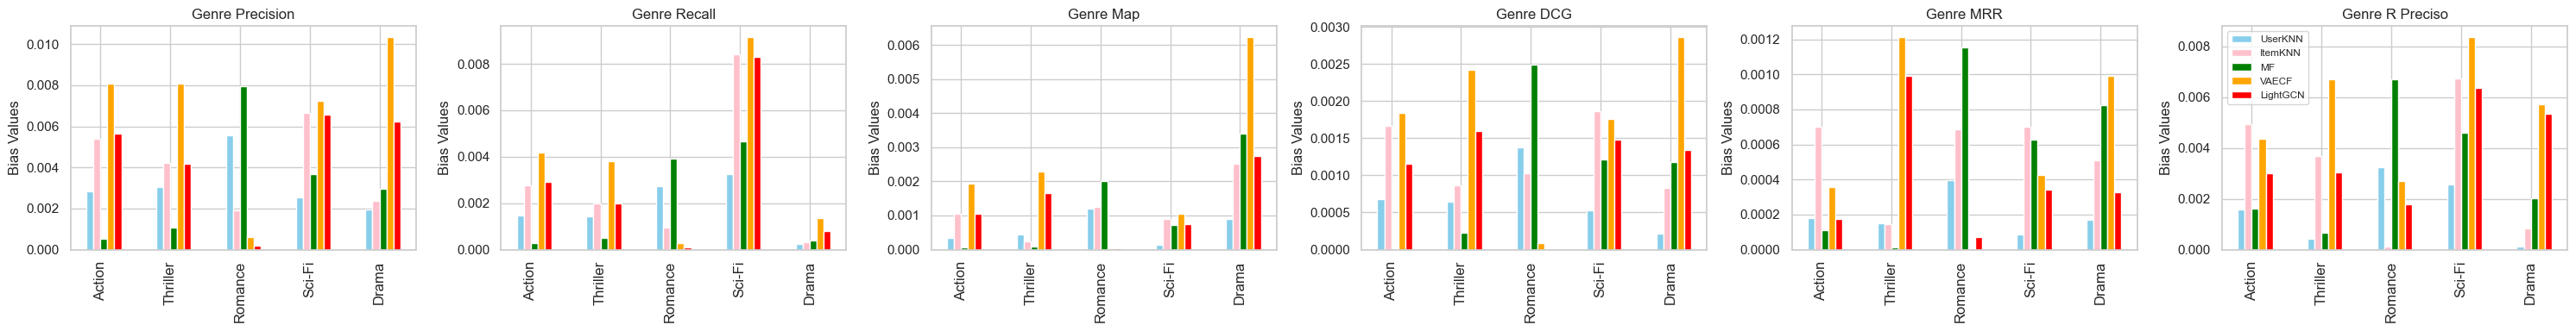

In [49]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="whitegrid")

matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]

labels = compare_genres
titles = [
    "Genre Precision",
    "Genre Recall",
    "Genre Map",
    "Genre DCG",
    "Genre MRR",
    "Genre R Preciso",
]


fig, axs = plt.subplots(1, 6, figsize=(30, 4))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.1  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label="UserKNN"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="pink", label="ItemKNN"
    )
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_3[i]), bar_width, color="green", label="MF"
    )
    axs[i].bar(
        x + 3 * bar_width / 2, abs(matrices_4[i]), bar_width, color="orange", label="VAECF"
    )
    axs[i].bar(
        x + 5 * bar_width / 2, abs(matrices_5[i]), bar_width, color="red", label="LightGCN"
    )
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)
    axs[i].axhline(y=0, color='black', linewidth=0.5)
    axs[i].set_title(titles[i])
    # axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Bias Values")
    axs[i].tick_params(axis="x", rotation=90)
handles, labels = axs[0].get_legend_handles_labels()

plt.legend(handles, labels, loc="upper left", fontsize="8.5")

# Adjust layout
plt.tight_layout()
plt.savefig("100k_all.pdf", format="pdf")

plt.show()

In [50]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [51]:
gp_sum

[0.028300246022634045,
 0.06752932095149575,
 0.04735875567218856,
 0.05284490004191491,
 0.03687868350554912]

In [52]:
gr_sum

[0.034043719068074636,
 0.0748939934632972,
 0.06987493575527312,
 0.05216615587493526,
 0.03724239502499824]

In [53]:
gm_sum

[0.004021374128561666,
 0.017608614236904463,
 0.011822017946587398,
 0.013762529646796352,
 0.008962711529850266]

In [54]:
gdcg_sum

[0.006307287442772572,
 0.01814120828837455,
 0.015313039322092397,
 0.014423979533454132,
 0.010116629145957453]

In [55]:
gmrr_sum

[0.0017327635402781386,
 0.007073451173631905,
 0.008049846747490432,
 0.005663659699868925,
 0.004191425829967416]

In [56]:
grp_sum

[0.01783365942987277,
 0.05677678804875648,
 0.052220792862854824,
 0.0487881592877394,
 0.03589207028059627]